In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [58]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [59]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -5.9285, -27.7758],
        [-20.7027, -76.5018],
        [ 36.2673, 140.2303],
        [ 10.9046,  41.8166]], grad_fn=<AddBackward0>)
tensor([[ 1.2219e-03,  9.8583e+00],
        [-3.6339e+00,  6.6149e-01],
        [ 3.4755e-03,  2.8841e+01],
        [ 4.8847e-01,  1.0591e+01],
        [-1.0303e+01,  8.8898e-02]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [60]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
# y = x[:, 0] * x[:, 2] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [61]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

checkpoint directory created: ./model
saving model version 0.0
Error in callback <function flush_figures at 0x7ca479b18180> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [ ]:
def get_tau(step, total_steps, tau_start=2.0, tau_end=0.01):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [ ]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 1000

grid_update_freq = 200

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        if epoch % grid_update_freq == 0:
            model.update_grid(batch_x)
        # if (epoch + 1) % grid_update_freq == 0:
        #     for param_group in optimizer.param_groups:
        #         param_group['lr'] *= 0.8
                
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.tau = new_tau

        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        lamb = 0.00001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/1000], Train Loss: 0.3187, Test Loss: 0.3060, reg: 110.9258
Epoch [20/1000], Train Loss: 0.2756, Test Loss: 0.2671, reg: 118.6067
Epoch [30/1000], Train Loss: 0.2711, Test Loss: 0.2686, reg: 120.1259
Epoch [40/1000], Train Loss: 0.2670, Test Loss: 0.2655, reg: 123.0436
Epoch [50/1000], Train Loss: 0.2649, Test Loss: 0.2671, reg: 123.6165
Epoch [60/1000], Train Loss: 0.2640, Test Loss: 0.2662, reg: 124.5664
Epoch [70/1000], Train Loss: 0.2634, Test Loss: 0.2670, reg: 125.5062
Epoch [80/1000], Train Loss: 0.2625, Test Loss: 0.2662, reg: 127.0517
Epoch [90/1000], Train Loss: 0.2602, Test Loss: 0.2647, reg: 129.5654
Epoch [100/1000], Train Loss: 0.2113, Test Loss: 0.1988, reg: 134.7119
Epoch [110/1000], Train Loss: 0.1183, Test Loss: 0.1253, reg: 140.1336
Epoch [120/1000], Train Loss: 0.0585, Test Loss: 0.0557, reg: 151.8703
Epoch [130/1000], Train Loss: 0.0147, Test Loss: 0.0144, reg: 148.8607
Epoch [140/1000], Train Loss: 0.0062, Test Loss: 0.0071, reg: 152.8046
Epoch [150/1000

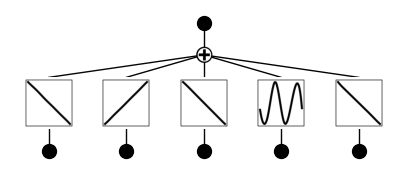

In [ ]:
model.plot()

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.3112e+00,  7.2052e-01,  4.0759e-01,  6.3297e-02, -6.9492e-02,
          -1.3125e-01, -7.9175e-03,  2.5845e-03]],

        [[-1.7849e+00, -1.3860e+00, -6.6246e-01, -1.8773e-01,  2.2796e-01,
           4.3063e-01,  6.2075e-01,  5.2986e-01]],

        [[ 1.3409e+00,  9.5636e-01,  4.3605e-01,  7.6219e-02, -1.4172e-01,
          -2.1443e-01, -1.9973e-01,  3.1275e-03]],

        [[ 3.0595e+00, -4.8333e-01, -8.4864e-01,  1.4773e+00, -1.3165e+00,
           4.3479e-01,  1.1103e+00, -5.4682e+00]],

        [[ 1.6612e+00,  8.1083e-01,  4.1879e-01,  1.1066e-01, -8.2183e-02,
          -9.3971e-02, -2.6204e-02,  3.1117e-01]]], device='cuda:0')
act_fun.0.scale_base tensor([[-1.2633e+00],
        [ 9.4045e-01],
        [-1.2728e+00],
        [-4.3539e-06],
        [-1.5160e+00]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.7720],
        [0.5513],
        [0.7411],
        [1.5380],
        [0.8202]], device='cuda:0')
act_fun.0.logits tensor([[[ 1.6744e-04,  3.4187e+00,

# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

In [29]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [30]:
def get_reg_lambda(epoch, epochs, tau_start=1e-6, tau_end=1e-3):
    return tau_start * (tau_end / tau_start) ** (epoch / epochs)

In [62]:
def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    grid_update_freq = 200

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            if batch_idx == batches - 1:
                indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
            else:
                indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
            
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_reg_lambda(epoch, epochs, tau_start=lr, tau_end=1e-3)
                    
            new_tau = get_tau(epoch, epochs, tau_start=5.0, tau_end=0.5)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # entropy regularization
            entropy_total = 0.0
            num_layers = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_total += entropy_i.mean()
                    num_layers += 1
            if num_layers > 0:
                entropy_avg = entropy_total / num_layers
            else:
                entropy_avg = 0.0
            
            # lamb_ent = 0.0
            # lamb_ent = 1e-1
            lamb_ent = get_reg_lambda(epoch, epochs, tau_start=1e-6, tau_end=1e-1)
            lamb = 1e-6
            # lamb = get_reg_lambda(epoch, epochs, tau_start=1e-7, tau_end=1e-6)
            # lamb_sp = 1e-3
            
            coeff_l1_total = 0.0
            coeff_diff_l1_total = 0.0
            num_layers = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    coeff_l1_total += torch.sum(torch.mean(torch.abs(module.coef), dim=1))
                    coeff_diff_l1_total += torch.sum(torch.mean(torch.abs(torch.diff(module.coef)), dim=1))
                    num_layers += 1
            if num_layers > 0:
                coeff_l1_avg = coeff_l1_total / num_layers
                coeff_diff_l1_avg = coeff_diff_l1_total / num_layers
            else:
                coeff_l1_avg = 0.0
                coeff_diff_l1_avg = 0.0     
            
            lamb_coef = 0.01    # для коэффициентов сплайнов
            lamb_coefdiff = 0.01 # для гладкости коэффициентов
            
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
            loss = train_loss + lamb * l1_reg + lamb_ent * entropy_avg + lamb_coef * coeff_l1_avg + lamb_coefdiff * coeff_diff_l1_avg
            # loss = train_loss + lamb_ent * entropy_avg + lamb_sp * reg_spline
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')
        

## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [63]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


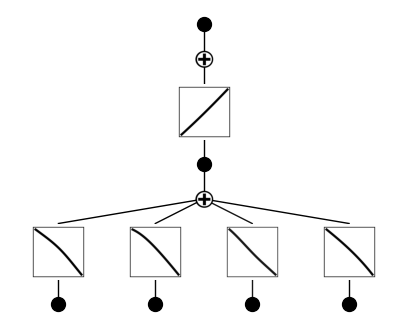

In [64]:
model = nexusKAN(width=[4, 1, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [65]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=5000)

Epoch [10/5000], Train Loss: 3.6091, Test Loss: 2.5492, reg: 113.5223
Epoch [20/5000], Train Loss: 1.3966, Test Loss: 1.4324, reg: 116.3615
Epoch [30/5000], Train Loss: 0.8301, Test Loss: 0.8160, reg: 118.8533
Epoch [40/5000], Train Loss: 0.6301, Test Loss: 0.6661, reg: 120.0357
Epoch [50/5000], Train Loss: 0.5177, Test Loss: 0.5383, reg: 119.9298
Epoch [60/5000], Train Loss: 0.4777, Test Loss: 0.4804, reg: 119.8105
Epoch [70/5000], Train Loss: 0.4508, Test Loss: 0.4603, reg: 119.3085
Epoch [80/5000], Train Loss: 0.4239, Test Loss: 0.4315, reg: 119.2732
Epoch [90/5000], Train Loss: 0.3968, Test Loss: 0.4029, reg: 119.2624
Epoch [100/5000], Train Loss: 0.3712, Test Loss: 0.3815, reg: 119.0403
Epoch [110/5000], Train Loss: 0.3463, Test Loss: 0.3591, reg: 118.7743
Epoch [120/5000], Train Loss: 0.3222, Test Loss: 0.3361, reg: 118.7194
Epoch [130/5000], Train Loss: 0.2997, Test Loss: 0.3155, reg: 118.8496
Epoch [140/5000], Train Loss: 0.2814, Test Loss: 0.2991, reg: 119.0219
Epoch [150/5000

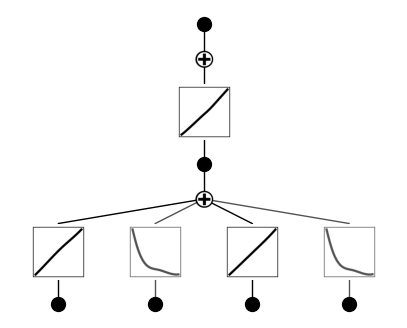

In [66]:
model.plot()

In [41]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [42]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [48]:
model = nexusKAN(width=[2, 1, 1], grid=5, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [49]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=5000)

Epoch [10/5000], Train Loss: 1.5849, Test Loss: 1.4503, reg: 66.0594
Epoch [20/5000], Train Loss: 0.5826, Test Loss: 0.4749, reg: 71.2834
Epoch [30/5000], Train Loss: 0.2981, Test Loss: 0.2036, reg: 76.3363
Epoch [40/5000], Train Loss: 0.1541, Test Loss: 0.1102, reg: 79.0014
Epoch [50/5000], Train Loss: 0.0769, Test Loss: 0.0532, reg: 80.9042
Epoch [60/5000], Train Loss: 0.0378, Test Loss: 0.0213, reg: 83.3622
Epoch [70/5000], Train Loss: 0.0254, Test Loss: 0.0181, reg: 85.2722
Epoch [80/5000], Train Loss: 0.0195, Test Loss: 0.0125, reg: 86.3962
Epoch [90/5000], Train Loss: 0.0155, Test Loss: 0.0094, reg: 87.1164
Epoch [100/5000], Train Loss: 0.0135, Test Loss: 0.0084, reg: 87.5659
Epoch [110/5000], Train Loss: 0.0118, Test Loss: 0.0073, reg: 88.0787
Epoch [120/5000], Train Loss: 0.0105, Test Loss: 0.0063, reg: 88.6368
Epoch [130/5000], Train Loss: 0.0095, Test Loss: 0.0059, reg: 89.1963
Epoch [140/5000], Train Loss: 0.0087, Test Loss: 0.0055, reg: 89.8173
Epoch [150/5000], Train Loss:

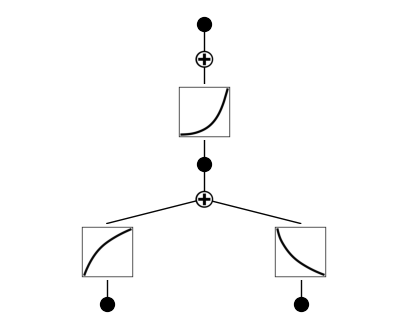

In [50]:
model.plot()

In [51]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.0050, 0.9950]],

        [[0.0050, 0.9950]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [52]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [53]:
model = nexusKAN(width=[4, 2, 1], grid=5, k=3, seed=42, device=device)

checkpoint directory created: ./model
saving model version 0.0


In [54]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=5000)

Epoch [10/5000], Train Loss: 245.9202, Test Loss: 150.0132, reg: 180.8928
Epoch [20/5000], Train Loss: 104.3760, Test Loss: 58.6199, reg: 197.8656
Epoch [30/5000], Train Loss: 49.3549, Test Loss: 48.5864, reg: 232.4308
Epoch [40/5000], Train Loss: 29.4550, Test Loss: 25.0561, reg: 246.1453
Epoch [50/5000], Train Loss: 18.2584, Test Loss: 11.8361, reg: 247.4733
Epoch [60/5000], Train Loss: 11.8255, Test Loss: 8.2263, reg: 253.5813
Epoch [70/5000], Train Loss: 8.3841, Test Loss: 5.4781, reg: 265.1936
Epoch [80/5000], Train Loss: 5.9996, Test Loss: 3.9050, reg: 274.2854
Epoch [90/5000], Train Loss: 4.3997, Test Loss: 2.6348, reg: 281.0263
Epoch [100/5000], Train Loss: 3.3093, Test Loss: 2.0056, reg: 285.5655
Epoch [110/5000], Train Loss: 2.6123, Test Loss: 1.6350, reg: 290.0019
Epoch [120/5000], Train Loss: 2.1900, Test Loss: 1.4558, reg: 293.7922
Epoch [130/5000], Train Loss: 1.9253, Test Loss: 1.2629, reg: 297.1612
Epoch [140/5000], Train Loss: 1.7507, Test Loss: 1.1349, reg: 299.8000
E

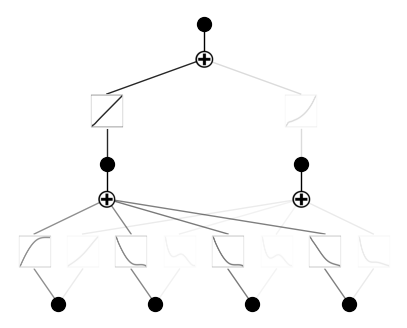

In [55]:
model.plot()

In [56]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.4030, 0.4040, 0.1940],
         [0.0000, 0.0010, 0.9990]],

        [[0.8690, 0.0080, 0.1220],
         [0.0020, 0.0260, 0.9730]],

        [[0.4160, 0.4490, 0.1350],
         [0.2880, 0.0520, 0.6600]],

        [[0.4060, 0.4180, 0.1750],
         [0.0000, 0.0000, 1.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.9820, 0.0180]],

        [[0.9960, 0.0040]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [57]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


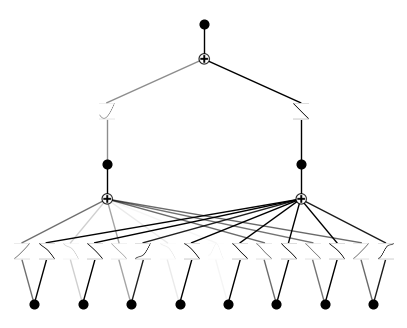

In [58]:
model = nexusKAN(width=[8, 2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [59]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=5000)

Epoch [10/5000], Train Loss: 2.3566, Test Loss: 2.2838, reg: 282.6912
Epoch [20/5000], Train Loss: 0.8634, Test Loss: 0.9882, reg: 312.2060
Epoch [30/5000], Train Loss: 0.4483, Test Loss: 0.4881, reg: 333.0960
Epoch [40/5000], Train Loss: 0.2728, Test Loss: 0.4842, reg: 349.7693
Epoch [50/5000], Train Loss: 0.2167, Test Loss: 0.3219, reg: 364.4552
Epoch [60/5000], Train Loss: 0.1813, Test Loss: 0.2704, reg: 375.9656
Epoch [70/5000], Train Loss: 0.1553, Test Loss: 0.2680, reg: 385.3483
Epoch [80/5000], Train Loss: 0.1466, Test Loss: 0.2426, reg: 392.3095
Epoch [90/5000], Train Loss: 0.1424, Test Loss: 0.2145, reg: 397.2920
Epoch [100/5000], Train Loss: 0.1670, Test Loss: 0.2114, reg: 400.4860
Epoch [110/5000], Train Loss: 0.1447, Test Loss: 0.2100, reg: 402.7274
Epoch [120/5000], Train Loss: 0.1315, Test Loss: 0.2119, reg: 404.6201
Epoch [130/5000], Train Loss: 0.1314, Test Loss: 0.2074, reg: 406.8260
Epoch [140/5000], Train Loss: 0.1302, Test Loss: 0.2050, reg: 408.9647
Epoch [150/5000

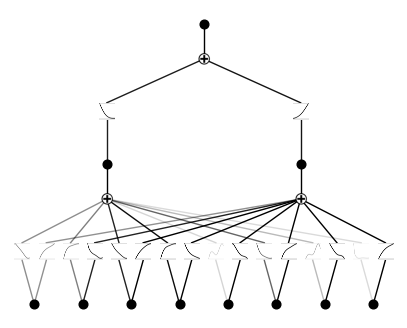

In [60]:
model.plot()

In [61]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.3060, 0.0310, 0.0750, 0.0950, 0.4930],
         [0.0380, 0.0010, 0.6190, 0.3220, 0.0200]],

        [[0.0530, 0.0390, 0.0420, 0.0360, 0.8300],
         [0.0840, 0.0140, 0.6280, 0.2130, 0.0610]],

        [[0.0480, 0.4500, 0.2560, 0.1200, 0.1250],
         [0.0000, 0.0040, 0.9950, 0.0000, 0.0010]],

        [[0.6790, 0.0220, 0.0510, 0.1220, 0.1260],
         [0.0010, 0.0120, 0.9850, 0.0000, 0.0030]],

        [[0.0970, 0.0400, 0.3300, 0.0510, 0.4820],
         [0.1250, 0.0000, 0.0000, 0.8700, 0.0040]],

        [[0.1120, 0.0480, 0.2780, 0.1000, 0.4620],
         [0.3740, 0.4030, 0.0550, 0.0000, 0.1690]],

        [[0.4000, 0.0920, 0.1150, 0.1230, 0.2690],
         [0.8830, 0.0020, 0.0050, 0.1090, 0.0010]],

        [[0.1230, 0.0520, 0.1370, 0.1330, 0.5550],
         [0.0000, 0.4070, 0.1800, 0.2780, 0.1340]]], device='cuda:0',
       grad_fn=<RoundBackward1>)
tensor([[[1., 0.]],

        [[1., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
